In [102]:
# load dot env
from dotenv import load_dotenv
import os
load_dotenv()

False

In [103]:
# import all libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels
import yfinance as yf
import os
from util import get_data

In [1]:
CURRENCY = '^DJI'
MODEL_TYPE = "Naive"
COIN_ORDERS = 0.005
DAYS = 30
START_CASH = 10_000

btc = get_data(CURRENCY)
btc.head()

NameError: name 'get_data' is not defined

' plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) '

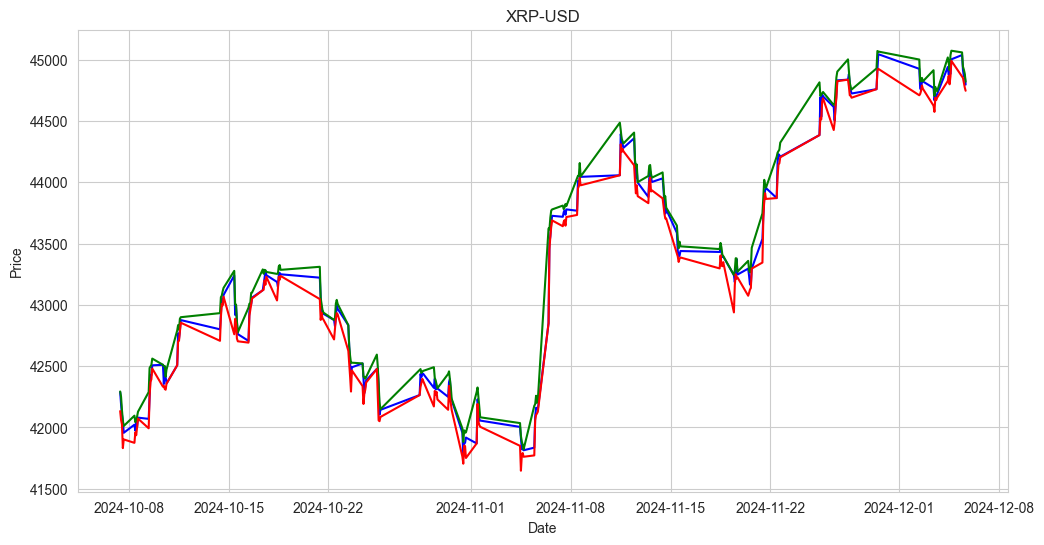

In [105]:
# plot open, high, and low
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))

plt.plot(btc['Open'], label='Open', color='blue')
plt.plot(btc['High'], label='High', color='green')
plt.plot(btc['Low'], label='Low', color='red')

plt.title('XRP-USD')
plt.xlabel('Date')
plt.ylabel('Price')

DAYS = 3

""" plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) """

In [106]:
import random

# Initialize Positions DataFrame
positions = pd.DataFrame(columns=["Date Bought", "Price Bought", "Price Sold", "Value Sold", "Time Sold", "Time Held", "Gross Profit"])

cash_balance = START_CASH  # Starting cash
crypto_balance = 0
positions = pd.DataFrame(columns=[
    "Date Bought", "Price Bought", "Price Sold", "Value Sold", 
    "Gross Profit", "Time Sold", "Time Held", "Type"
])
portfolio_value = []
profits_over_time = []
cash_over_time = []
crypto_over_time = []
time = []

def reset():
    global cash_balance, crypto_balance, positions, portfolio_value, profits_over_time, cash_over_time, crypto_over_time, time
    cash_balance = START_CASH  # Starting cash
    crypto_balance = 0
    positions = pd.DataFrame(columns=[
        "Date Bought", "Price Bought", "Price Sold", "Value Sold", 
        "Gross Profit", "Time Sold", "Time Held", "Coins", "Type"
    ])
    portfolio_value = []
    profits_over_time = []
    cash_over_time = []
    crypto_over_time = []
    time = []

In [107]:
def execute_trades(data, trail_pct=0.05, coin_orders=10):
    """
    Executes trades on the data, using trailing stop orders to manage risk.

    Parameters:
    - data: DataFrame of price data.
    - trail_pct: Percentage to trail the market price for stop orders.
    - coin_orders: Number of coins to buy or sell in a single transaction.
    """
    global cash_balance, crypto_balance, positions

    # Add 'Trailing Stop' column to positions DataFrame to track stop prices
    if "Trailing Stop" not in positions.columns:
        positions["Trailing Stop"] = None

    for i in range(0, len(data) - 1, 1):  # Iterate through price data
        row = data.iloc[i]
        price = row['Open']
        date = row.name

        # Check trailing stop criteria for active positions
        for idx, position in positions[positions["Price Sold"].isna()].iterrows():
            if position["Type"] == "buy":
                # Adjust trailing stop if market moves up
                new_trailing_stop = max(position["Trailing Stop"] or 0, price * (1 - trail_pct))
                positions.loc[idx, "Trailing Stop"] = new_trailing_stop

                # Sell position if price drops below the trailing stop
                if price <= new_trailing_stop:
                    coins_to_sell = min(coin_orders, crypto_balance)
                    crypto_balance -= coins_to_sell
                    cash_balance += coins_to_sell * price
                    gross_profit = coins_to_sell * (price - position["Price Bought"])
                    positions.loc[idx, "Price Sold"] = price
                    positions.loc[idx, "Value Sold"] = price * coins_to_sell
                    positions.loc[idx, "Gross Profit"] = gross_profit
                    positions.loc[idx, "Time Sold"] = date
                    positions.loc[idx, "Coins"] = coin_orders
                    positions.loc[idx, "Time Held"] = date - position["Date Bought"]

            elif position["Type"] == "short":
                # Adjust trailing stop if market moves down
                new_trailing_stop = min(position["Trailing Stop"] or float('inf'), price * (1 + trail_pct))
                positions.loc[idx, "Trailing Stop"] = new_trailing_stop

                # Cover position if price rises above the trailing stop
                if price >= new_trailing_stop:
                    coins_to_cover = coin_orders
                    cash_balance -= coins_to_cover * price
                    gross_profit = coins_to_cover * (position["Price Bought"] - price)
                    positions.loc[idx, "Price Sold"] = price
                    positions.loc[idx, "Value Sold"] = price * coins_to_cover
                    positions.loc[idx, "Gross Profit"] = gross_profit
                    positions.loc[idx, "Time Sold"] = date
                    positions.loc[idx, "Coins"] = coin_orders
                    positions.loc[idx, "Time Held"] = date - position["Date Bought"]

        # Random action: Buy, Short, or Nothing
        probs = [0.4, 0.4, 0.2]  # Probabilities for buy, nothing, short
        action = np.random.choice(["buy", "nothing", "short"], p=probs)

        if action == "buy" and cash_balance > price * coin_orders:
            # Execute Buy
            crypto_balance += coin_orders
            cash_balance -= price * coin_orders
            positions = pd.concat([positions, pd.DataFrame({
                "Date Bought": [date],
                "Price Bought": [price],
                "Price Sold": [None],
                "Value Sold": [None],
                "Gross Profit": [None],
                "Time Sold": [None],
                "Time Held": [None],
                "Coins": [coin_orders],
                "Type": ["buy"],
                "Trailing Stop": [price * (1 - trail_pct)]
            })], ignore_index=True)

        elif action == "short" and cash_balance > price * coin_orders:
            # Open Short Position
            cash_balance += price * coin_orders  # Borrow and sell immediately
            positions = pd.concat([positions, pd.DataFrame({
                "Date Bought": [date],
                "Price Bought": [price],
                "Price Sold": [None],
                "Value Sold": [None],
                "Gross Profit": [None],
                "Time Sold": [None],
                "Time Held": [None],
                "Coins": [coin_orders],
                "Type": ["short"],
                "Trailing Stop": [price * (1 + trail_pct)]
            })], ignore_index=True)

        # Track portfolio and balances
        total_portfolio_value = cash_balance + (crypto_balance * price)
        # subtract the current price of the short position from portfolio value
        current_positions = positions[positions["Price Sold"].isna()]
        current_positions = current_positions[current_positions["Type"] == "short"]
        total_portfolio_value -= (current_positions["Price Bought"] * current_positions["Coins"]).sum()
        portfolio_value.append((date, total_portfolio_value))
        profits_over_time.append((date, positions["Gross Profit"].sum()))
        cash_over_time.append((date, cash_balance))
        crypto_over_time.append((date, crypto_balance))
        time.append(date)

    # At the end, realize all positions
    row = data.iloc[-1]
    price = row['Open']
    date = row.name

    for idx, position in positions[positions["Price Sold"].isna()].iterrows():
        if position["Type"] == "buy":
            coins_to_sell = min(coin_orders, crypto_balance)
            crypto_balance -= coins_to_sell
            cash_balance += coins_to_sell * price
            gross_profit = coins_to_sell * (price - position["Price Bought"])
            positions.loc[idx, "Price Sold"] = price
            positions.loc[idx, "Value Sold"] = price * coins_to_sell
            positions.loc[idx, "Gross Profit"] = gross_profit
            positions.loc[idx, "Time Sold"] = date
            positions.loc[idx, "Coins"] = coin_orders
            positions.loc[idx, "Time Held"] = date - position["Date Bought"]

        elif position["Type"] == "short":
            coins_to_cover = coin_orders
            cash_balance -= coins_to_cover * price
            gross_profit = coins_to_cover * (position["Price Bought"] - price)
            positions.loc[idx, "Price Sold"] = price
            positions.loc[idx, "Value Sold"] = price * coins_to_cover
            positions.loc[idx, "Gross Profit"] = gross_profit
            positions.loc[idx, "Time Sold"] = date
            positions.loc[idx, "Coins"] = coin_orders
            positions.loc[idx, "Time Held"] = date - position["Date Bought"]

    # Track final portfolio and balances
    total_portfolio_value = cash_balance + (crypto_balance * price)
    
    portfolio_value.append((date, total_portfolio_value))
    profits_over_time.append((date, positions["Gross Profit"].sum()))
    cash_over_time.append((date, cash_balance))
    crypto_over_time.append((date, crypto_balance))
    time.append(date)

    # calculate gross profit percentage
    positions['Profit Percentage'] = positions['Gross Profit'] / (positions['Price Bought'] * positions['Coins'])

# Example Execution
reset()
execute_trades(btc, coin_orders=COIN_ORDERS)

C:\Users\akash\AppData\Local\Temp\ipykernel_7440\2688258703.py:66: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [108]:
# Convert tracking lists to DataFrames
portfolio_df = pd.DataFrame(portfolio_value, columns=["Date", "Portfolio Value"])
profits_df = pd.DataFrame(profits_over_time, columns=["Date", "Cumulative Profit"])
cash_df = pd.DataFrame(cash_over_time, columns=["Date", "Cash Balance"])
crypto_df = pd.DataFrame(crypto_over_time, columns=["Date", "Crypto Balance"])

btc_price = [btc['Open'].loc[date] for date in time]
crypto_value = crypto_df["Crypto Balance"] * btc_price

In [109]:
crypto_value

0          0.000000
1        210.940098
2        210.527246
3        210.275801
4        419.565703
           ...     
208    11034.418145
209    11004.600879
210    10992.094395
211    10994.539609
212        0.000000
Name: Crypto Balance, Length: 213, dtype: float64

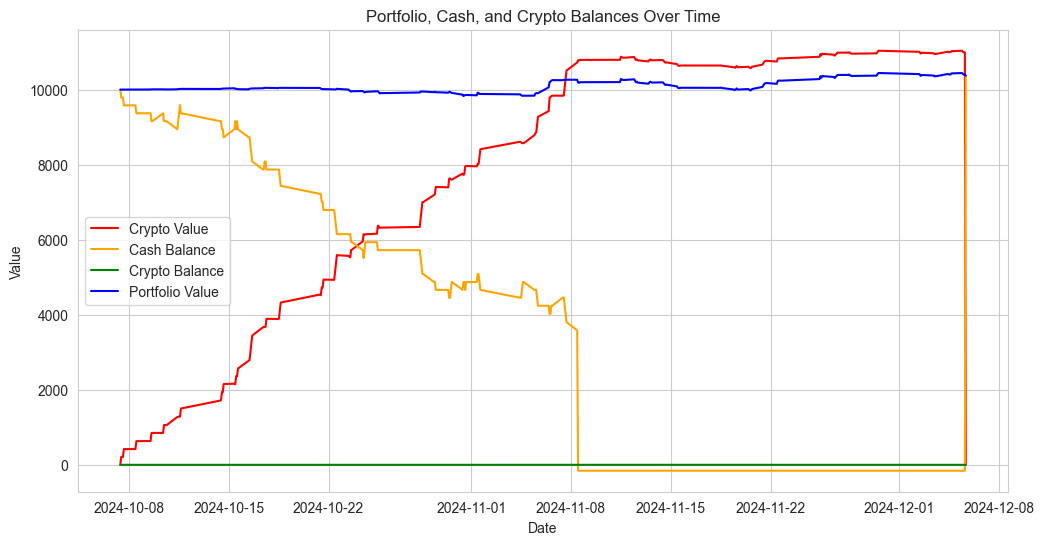

In [110]:
# Plot Portfolio, Cash, and Crypto Balances Over Time
plt.figure(figsize=(12, 6))

plt.plot(time, crypto_value, label="Crypto Value", color="red")
plt.plot(cash_df["Date"], cash_df["Cash Balance"], label="Cash Balance", color="orange")
plt.plot(crypto_df["Date"], crypto_df["Crypto Balance"], label="Crypto Balance", color="green")
plt.plot(portfolio_df["Date"], portfolio_df["Portfolio Value"], label="Portfolio Value", color="blue")

plt.title("Portfolio, Cash, and Crypto Balances Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()


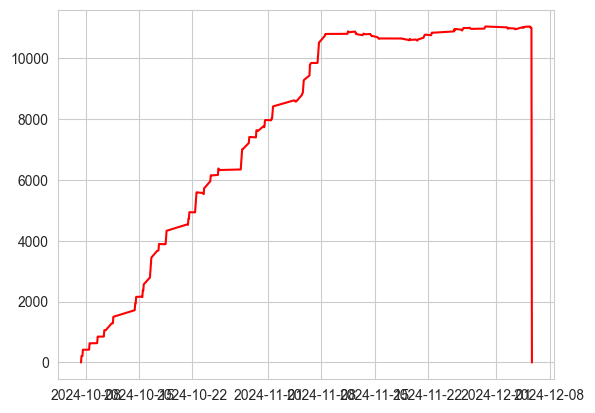

In [111]:
plt.plot(time, crypto_value, label="Crypto Value", color="red")
plt.show()

In [112]:
portfolio_df["Portfolio Value"]

0      10000.000000
1      10000.000000
2       9999.587148
3       9999.335703
4       9998.842754
           ...     
208    10440.556328
209    10410.739063
210    10398.232578
211    10400.677793
212    10370.400938
Name: Portfolio Value, Length: 213, dtype: float64

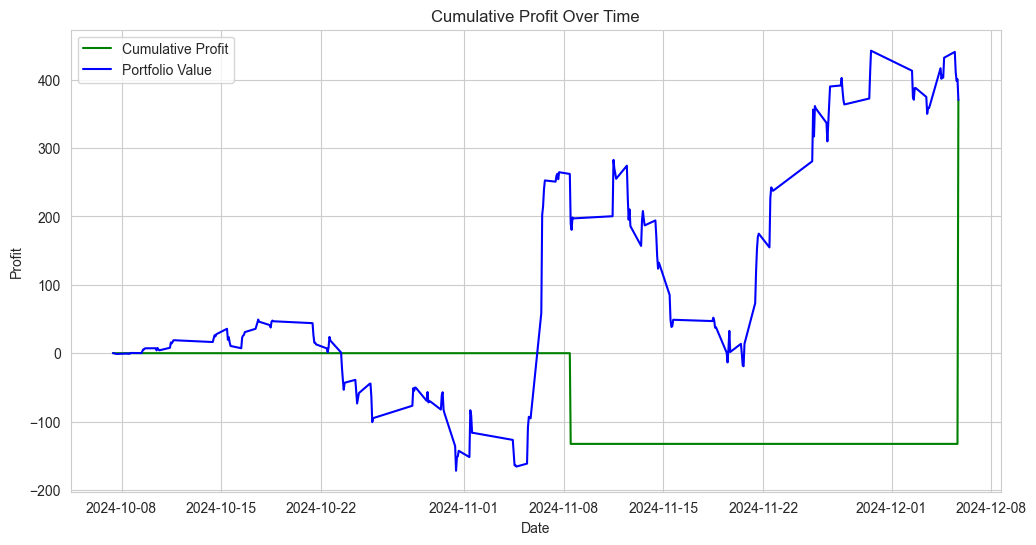

In [113]:
# Plot Profits Over Time
plt.figure(figsize=(12, 6))
plt.plot(profits_df["Date"], profits_df["Cumulative Profit"], label="Cumulative Profit", color="green")
plt.plot(portfolio_df["Date"], portfolio_df["Portfolio Value"] - portfolio_df["Portfolio Value"].iloc[0], label="Portfolio Value", color="blue")

plt.title("Cumulative Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.legend()
plt.show()

In [114]:
# show the rows with the highest gross profit
positions.sort_values('Gross Profit', ascending=True).head()

,Date Bought,Price Bought,Price Sold,Value Sold,Gross Profit,Time Sold,Time Held,Coins,Type,Trailing Stop,Profit Percentage
49,2024-10-31 11:00:00-04:00,41761.730469,44011.789062,220.058945,-11.250293,2024-11-08 11:00:00-05:00,8 days 01:00:00,0.005,short,43849.816992,-0.053878
56,2024-11-04 12:30:00-05:00,41823.171875,44011.789062,220.058945,-10.943086,2024-11-08 11:00:00-05:00,3 days 22:30:00,0.005,short,43904.974805,-0.05233
57,2024-11-04 14:00:00-05:00,41824.468750,44011.789062,220.058945,-10.936602,2024-11-08 11:00:00-05:00,3 days 21:00:00,0.005,short,43904.974805,-0.052298
51,2024-10-31 15:30:00-04:00,41917.761719,44011.789062,220.058945,-10.470137,2024-11-08 11:00:00-05:00,7 days 20:30:00,0.005,short,43904.974805,-0.049956
47,2024-10-30 15:30:00-04:00,42223.621094,44011.789062,220.058945,-8.94084,2024-11-08 11:00:00-05:00,8 days 20:30:00,0.005,short,43849.816992,-0.04235


In [115]:
import plotly.graph_objects as go
import pandas as pd

# Example DataFrames
# btc and positions should already be defined in your code

# Create a figure
fig = go.Figure()

# Add the 'Open' price line
fig.add_trace(go.Scatter(
    x=btc.index,
    y=btc['Open'],
    mode='lines',
    name='Open',
    line=dict(color='blue')
))

# Add buy positions
buy_positions = positions[positions['Type'] == 'buy']
for idx, position in buy_positions.iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        fig.add_trace(go.Scatter(
            x=[position['Date Bought'], position['Time Sold']],
            y=[position['Price Bought'], position['Price Sold']],
            mode='lines+markers',
            line=dict(color=color),
            name='Buy/Profit' if color == 'green' else 'Buy/Loss'
        ))

# Add short positions
short_positions = positions[positions['Type'] == 'short']
for idx, position in short_positions.iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        fig.add_trace(go.Scatter(
            x=[position['Date Bought'], position['Time Sold']],
            y=[position['Price Bought'], position['Price Sold']],
            mode='lines+markers',
            line=dict(color=color),
            name='Short/Profit' if color == 'green' else 'Short/Loss'
        ))

# Update layout for interactivity and style
fig.update_layout(
    title='XRP-USD',
    xaxis_title='Date',
    yaxis_title='Price',
    template='plotly_white',
    legend_title='Positions',
    xaxis=dict(range=[btc.index[-DAYS], btc.index[-1]])
)

# export to html
fig.write_html('plot.html')


' plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) '

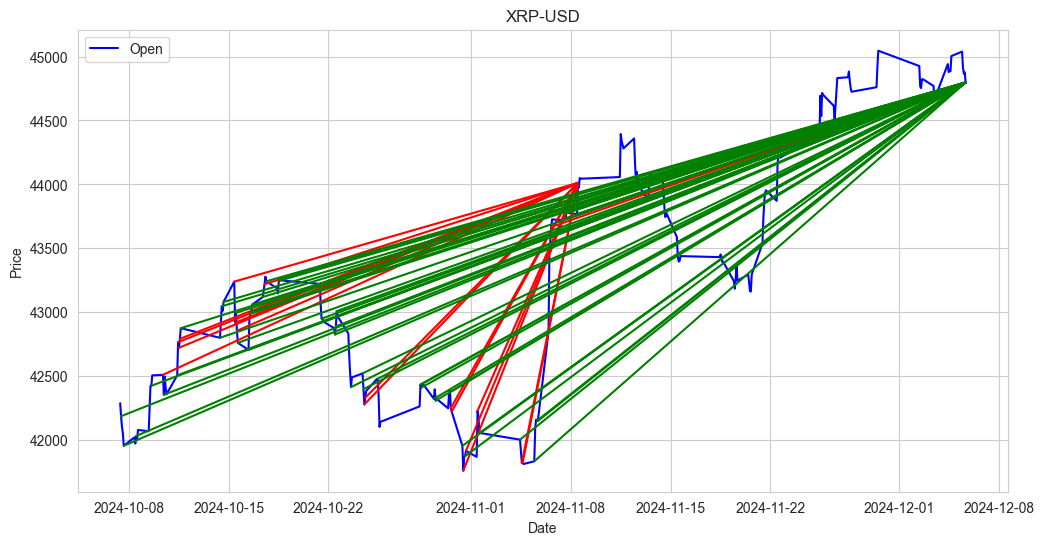

In [116]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))


plt.plot(btc['Open'], label='Open', color='blue')

# graph the buy positions
""" plt.plot(positions[positions['Type'] == 'buy']['Date Bought'], 
         positions[positions['Type'] == 'buy']['Price Bought'], 
         'o', markersize=5, color='green', label='Buy') """

# starting from price bought draw a line to price sold
for idx, position in positions[positions['Type'] == 'short'].iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        plt.plot([position['Date Bought'], position['Time Sold']], 
                 [position['Price Bought'], position['Price Sold']], 
                 color=color)

# starting from price bought draw a line to price sold
for idx, position in positions[positions['Type'] == 'buy'].iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        plt.plot([position['Date Bought'], position['Time Sold']], 
                 [position['Price Bought'], position['Price Sold']], 
                 color=color)
        
""" 
# graph the short positions
plt.plot(positions[positions['Type'] == 'short']['Date Bought'], 
         positions[positions['Type'] == 'short']['Price Bought'], 
         'o', markersize=5, color='red', label='Short') """



plt.legend()

plt.title('XRP-USD')
plt.xlabel('Date')
plt.ylabel('Price')

DAYS = 30

""" plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) """

In [117]:
# run the model 1000 times and calculate the min, max, average, and std of portfolio value and profit
values = ['min', 'max', 'mean', 'std', 'end', '1st', 'median', '3rd']
columns = ['PortfolioValue', 'CumulativeProfit']
result_df = pd.DataFrame(columns=[column + '_' + value for column in columns for value in values])
result_df.head()

,PortfolioValue_min,PortfolioValue_max,PortfolioValue_mean,PortfolioValue_std,PortfolioValue_end,PortfolioValue_1st,PortfolioValue_median,PortfolioValue_3rd,CumulativeProfit_min,CumulativeProfit_max,CumulativeProfit_mean,CumulativeProfit_std,CumulativeProfit_end,CumulativeProfit_1st,CumulativeProfit_median,CumulativeProfit_3rd


In [118]:
RUNS = 30

for i in range(RUNS):
    reset()
    execute_trades(btc, coin_orders=COIN_ORDERS)
    portfolio_df = pd.DataFrame(portfolio_value, columns=["Date", "Portfolio Value"])
    profits_df = pd.DataFrame(profits_over_time, columns=["Date", "Cumulative Profit"])

    for column in result_df.columns:
        dataframe = None
        if 'PortfolioValue' in column:
            dataframe = portfolio_df
        elif 'CumulativeProfit' in column:
            dataframe = profits_df
        
        if 'min' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].min()
        elif 'max' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].max()
        elif 'mean' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].mean()
        elif 'std' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].std()
        elif 'end' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].iloc[-1]
        elif '1st' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].quantile(0.25)
        elif 'median' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].median()
        elif '3rd' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].quantile(0.75)

        # print with /r
        print(f'\r{i} / {RUNS}', end='')

result_df.head()

C:\Users\akash\AppData\Local\Temp\ipykernel_7440\2688258703.py:66: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



0 / 30

C:\Users\akash\AppData\Local\Temp\ipykernel_7440\2688258703.py:66: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



1 / 30

C:\Users\akash\AppData\Local\Temp\ipykernel_7440\2688258703.py:82: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



...

C:\Users\akash\AppData\Local\Temp\ipykernel_7440\2688258703.py:66: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



28 / 30

C:\Users\akash\AppData\Local\Temp\ipykernel_7440\2688258703.py:82: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



29 / 30

,PortfolioValue_min,PortfolioValue_max,PortfolioValue_mean,PortfolioValue_std,PortfolioValue_end,PortfolioValue_1st,PortfolioValue_median,PortfolioValue_3rd,CumulativeProfit_min,CumulativeProfit_max,CumulativeProfit_mean,CumulativeProfit_std,CumulativeProfit_end,CumulativeProfit_1st,CumulativeProfit_median,CumulativeProfit_3rd
0,9820.323516,10522.311699,10133.719816,193.003955,10435.562969,9998.919805,10063.99252,10290.977051,-120.331699,435.562969,-49.093615,68.017201,435.562969,-120.331699,0.0,0.0
1,9877.309922,10468.416973,10121.21014,167.517939,10392.283711,9999.555195,10047.978066,10261.432051,-120.591016,392.283711,-49.678398,66.995993,392.283711,-120.591016,0.0,0.0
2,9816.542852,10490.624141,10114.460312,186.45782,10403.761699,9999.916387,10040.100371,10273.209297,-141.359512,403.761699,-58.497436,76.865378,403.761699,-141.359512,0.0,0.0
3,9851.554922,10448.928086,10104.728396,163.935745,10384.396289,9984.250176,10035.017031,10234.71957,-173.532852,384.396289,-71.807431,90.944036,384.396289,-173.532852,0.0,0.0
4,9859.308164,10330.090391,10052.66536,122.440684,10250.783594,9965.732969,10022.379258,10126.197812,-180.017813,250.783594,-75.731631,91.894663,250.783594,-180.017813,0.0,0.0


In [119]:
# format all columns as numeric
result_df = result_df.apply(pd.to_numeric, errors='coerce')

result_df.describe()

,PortfolioValue_min,PortfolioValue_max,PortfolioValue_mean,PortfolioValue_std,PortfolioValue_end,PortfolioValue_1st,PortfolioValue_median,PortfolioValue_3rd,CumulativeProfit_min,CumulativeProfit_max,CumulativeProfit_mean,CumulativeProfit_std,CumulativeProfit_end,CumulativeProfit_1st,CumulativeProfit_median,CumulativeProfit_3rd
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.0,30.0
mean,9846.662806,10440.648253,10097.859571,163.359420,10352.581143,9980.715286,10036.160452,10221.963812,-169.885277,352.581143,-70.224549,88.879402,352.581143,-168.421969,0.0,0.0
std,21.350927,78.558358,34.045193,26.677705,82.322267,18.461791,16.318730,66.702642,40.598758,82.322267,17.566814,17.518258,82.322267,40.622181,0.0,0.0
min,9800.143867,10261.510449,10017.925304,119.290146,10180.980352,9935.707129,10005.822461,10061.695723,-289.282109,180.980352,-122.206273,50.955290,180.980352,-289.282109,0.0,0.0
25%,9831.867896,10388.459121,10074.723569,145.481099,10304.080107,9967.459028,10022.765659,10181.901836,-192.238799,304.080107,-79.042909,79.112161,304.080107,-189.153203,0.0,0.0
50%,9850.512646,10441.693701,10097.549127,163.450724,10351.708613,9980.900430,10032.622002,10217.651494,-179.118418,351.708613,-73.427529,91.279396,351.708613,-176.705742,0.0,0.0
75%,9859.174580,10478.308335,10118.526705,178.012294,10400.591860,9998.832197,10046.128638,10266.375283,-144.775596,400.591860,-59.930601,98.296572,400.591860,-144.775596,0.0,0.0
max,9884.452266,10626.606387,10169.334387,229.234282,10523.815703,9999.916387,10071.665156,10364.718105,-73.326465,523.815703,-28.733541,144.126554,523.815703,-73.326465,0.0,0.0


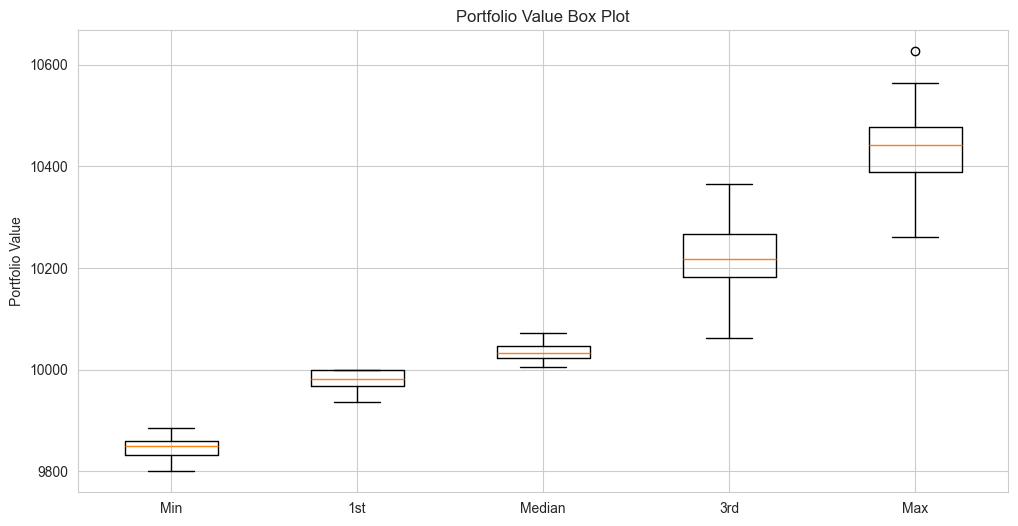

In [120]:
# create two box plots for portfolio value and cumulative profit
# use the mean of min, 1st, median, 3rd, and max
plt.figure(figsize=(12, 6))

plt.boxplot([result_df['PortfolioValue_min'], result_df['PortfolioValue_1st'],
                result_df['PortfolioValue_median'], result_df['PortfolioValue_3rd'],
                result_df['PortfolioValue_max']],
                labels=['Min', '1st', 'Median', '3rd', 'Max'])

plt.title('Portfolio Value Box Plot')
plt.ylabel('Portfolio Value')
plt.show()

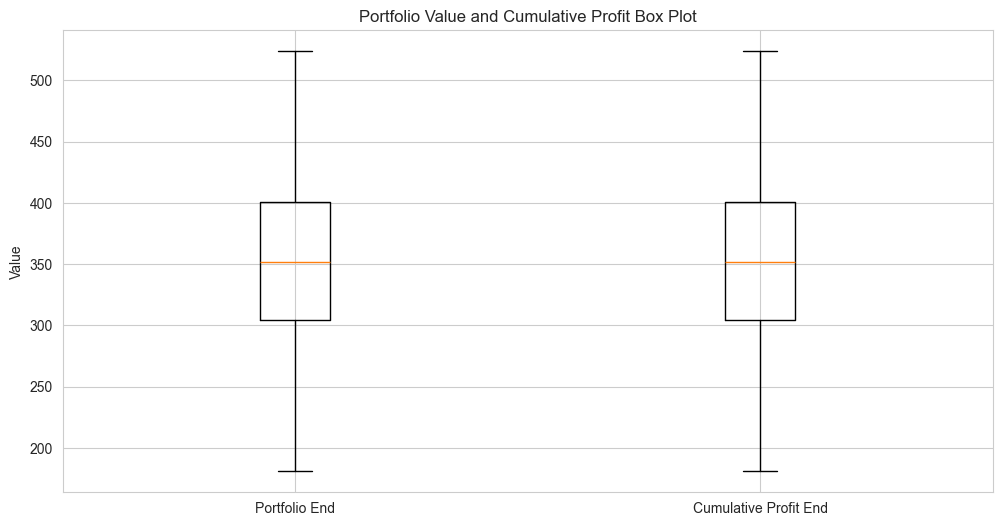

In [121]:
# create one box plot for portfolio value
plt.figure(figsize=(12, 6))

plt.boxplot([result_df['PortfolioValue_end'] - START_CASH, result_df['CumulativeProfit_end']],
                labels=['Portfolio End', 'Cumulative Profit End'])

plt.title('Portfolio Value and Cumulative Profit Box Plot')
plt.ylabel('Value')
plt.show()

In [122]:
result_df.to_csv('data/results/naive_trail_buy.csv')

In [123]:
# open every csv file in the data/results folder and create a box plot for PortfolioValue_end and CumulativeProfit_end
import glob

files = glob.glob('data/results/*.csv')

dfs = []
for file in files:
    dfs.append(pd.read_csv(file))

portfolio_value = []
cumulative_profit = []

for df in dfs:
    portfolio_value.append(df['PortfolioValue_end'])
    cumulative_profit.append(df['CumulativeProfit_end'])


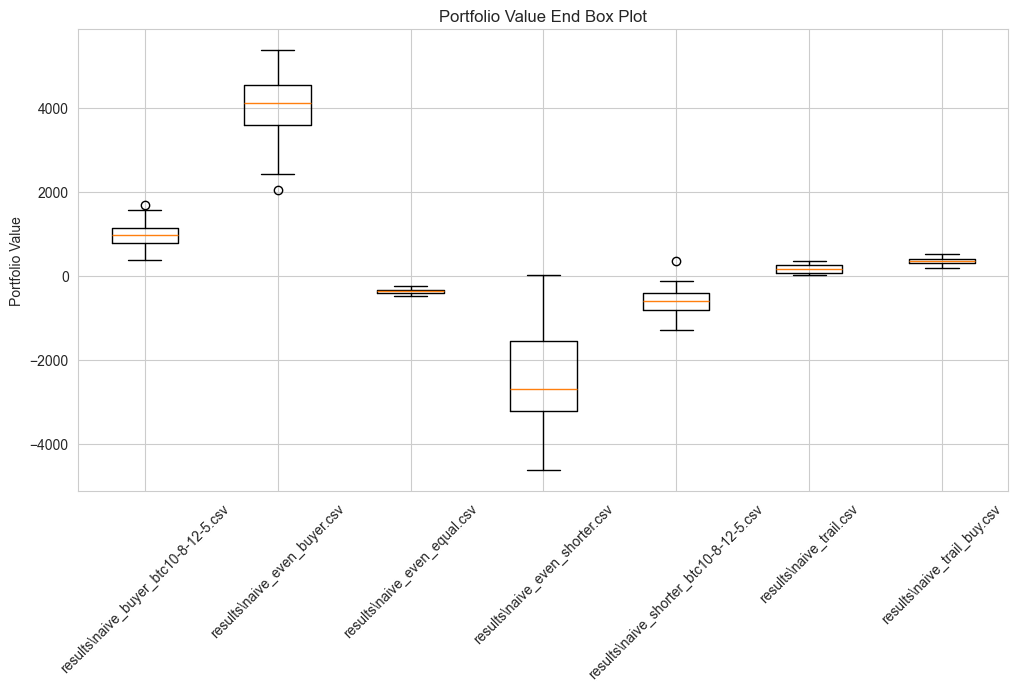

In [124]:
plt.figure(figsize=(12, 6))

plt.boxplot(cumulative_profit, labels=[file.split('/')[-1] for file in files])

plt.title('Portfolio Value End Box Plot')
plt.ylabel('Portfolio Value')
# slant the x-axis labels
plt.xticks(rotation=45)
plt.show()

Per Trade you can make 87 bucks profit ideally

In [138]:
btc["Open"].diff().abs().sum() / len(btc)

341.1898291168054

Max possible growth is 85%

In [137]:
btc["Open"].diff().abs().sum() * 100 / btc["Open"].iloc[0]

523.6967827628226